In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.cox_models import Cox_regression, p_values_Cox_regression, plot_coefficients
from src.utils.plots import Plots
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)

In [55]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
df_rsem_z_scores = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem_zscores_ref_all_samples.txt")
clean_df = pp.eliminate_nan_genes(df_rsem_z_scores, "Hugo_Symbol")


Esr1 = pp.gene_to_long(clean_df, "ESR1")


df_ESR1_merged = Esr1.merge(df_clinical_keep, on="Sample ID", how="inner")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)
Shape of the CSV: (20440, 819)
Max NaN per gene: 817
Genes before: 20440
Genes after: 20107


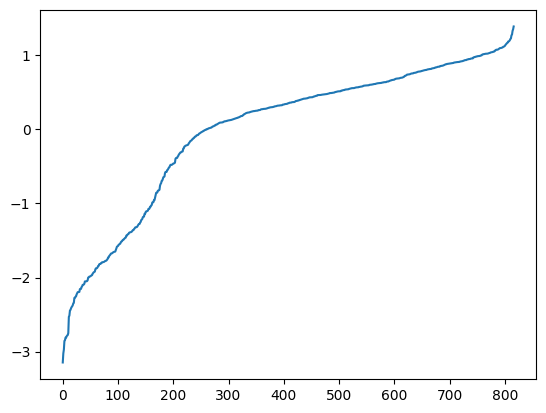

In [74]:

expression = df_ESR1_merged["expression"].values
lsit = sorted(expression)
plt.plot((lsit)) # plotting by columns
plt.show()


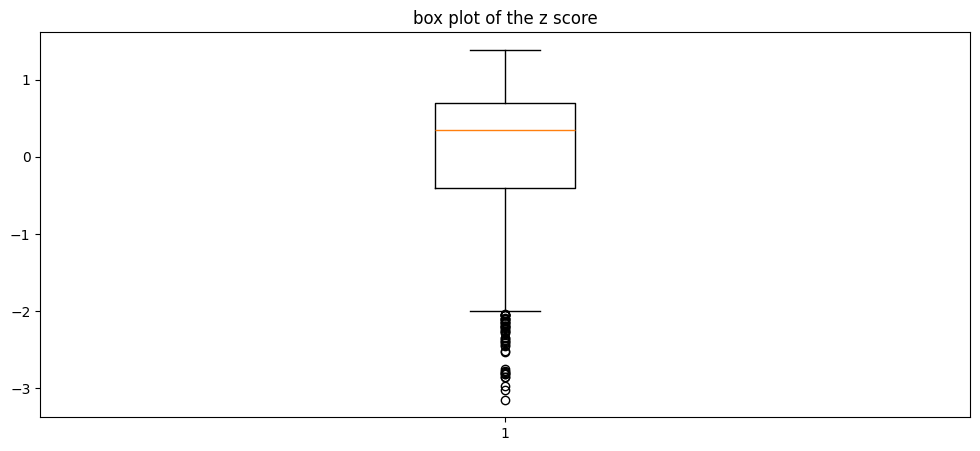

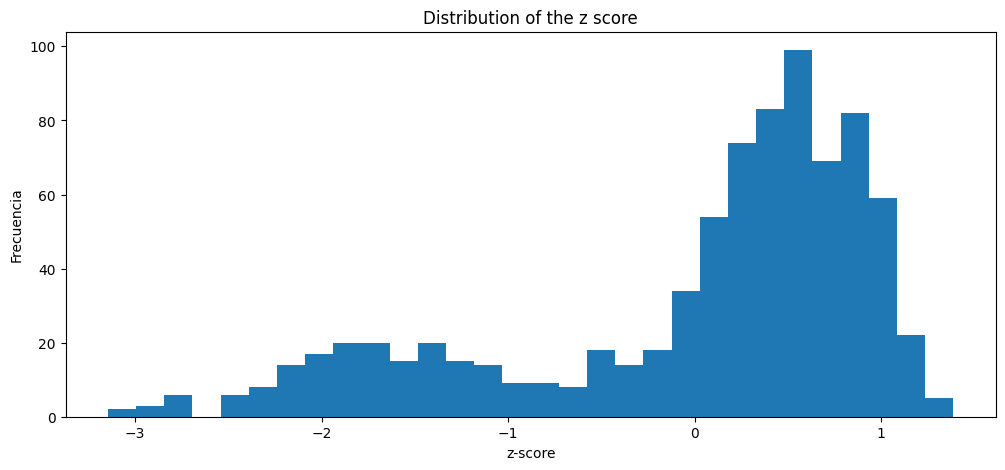

Min number ESR1: -3.1463
Max number ESR1: 1.388


In [56]:


ESR1 = df_ESR1_merged["expression"].values.reshape(-1,1)

scaler = StandardScaler()
z_score = scaler.fit_transform(ESR1)

plt.figure(figsize=(12,5))
plt.title("box plot of the z score")
plt.boxplot(z_score)
plt.show()

plt.figure(figsize=(12,5))
plt.hist(z_score, bins=30)
plt.title("Distribution of the z score")
plt.xlabel("z-score")
plt.ylabel("Frecuencia")
plt.show()
print(f"Min number ESR1: {ESR1.min()}")
print(f"Max number ESR1: {ESR1.max()}")
#plt.xlabel(f"Max number in ESR1:{ESR1.max()} ")

In [65]:
status = df_ESR1_merged["Overall Survival Status"].astype(str).str.strip()
df_ESR1_merged["event"] = status.str.contains("DECEASED", na=False) 
df_ESR1 = df_ESR1_merged.dropna(subset=["Overall Survival (Months)"])
X_ESR1 = df_ESR1[["expression"]]
Y_surv_ESR1 = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_ESR1
)

In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_ESR1, Y_surv_ESR1, train_size=0.80, test_size=0.20, random_state=42
)


In [67]:
betas_ESR1, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train, Y_train, X_test)

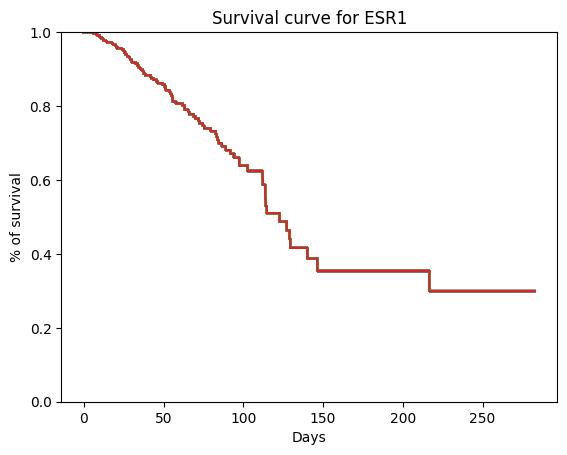

In [69]:
for fn in survival_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

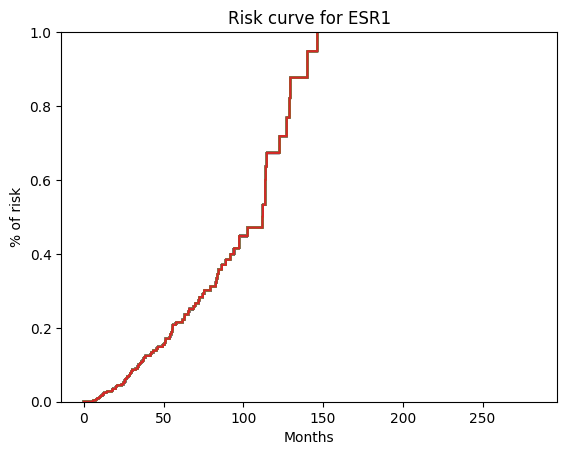

In [70]:
for fn in risk_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for ESR1")
plt.xlabel("Months")
plt.ylim(0, 1)
plt.ylabel("% of risk")
plt.show()

In [49]:
df_life_line_ESR1 = df_ESR1_merged[["expression", "event", "Overall Survival (Months)"]]
df_life_line_ESR1["expression"] = df_life_line_ESR1["expression"].apply(lambda single_expression : np.log2(single_expression))
df_life_line_ESR1 = df_life_line_ESR1.dropna(subset="Overall Survival (Months)")
df_life_line_ESR1 = df_life_line_ESR1.dropna(subset="expression")


In [50]:
p_values_Cox_regression(df_life_line_ESR1,event_col="event", duration_col="Overall Survival (Months)")

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.120768,1.128363,0.104616,-0.084277,0.325812,0.919177,1.385155,0.0,1.154386,0.248342,2.0096


In [75]:
print(betas_ESR1)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression     0.020605     0.020605     0.020605     0.020605     0.020605   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression     0.020605     0.020605     0.020604     0.020604     0.020604   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...     0.004185      0.00307     0.002212     0.001573   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression     0.001107     0.000773     0.000537     0.000372     0.000257   

alpha       10000.00000  
expression     0.000177  

[1 rows x 50 columns]


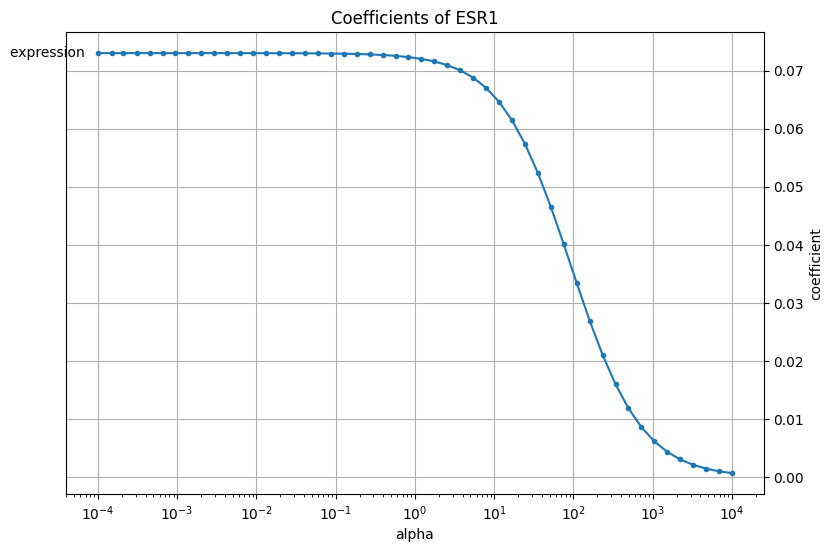

In [26]:
plot_coefficients(betas_ESR1, n_highlight=5, title="Coefficients of ESR1")